# JAR GROWTH INTERN ASSIGNMENT

## Sales Analysis

This notebook contains the solution for the **Jar Growth Intern Assessment** using Python. The analysis is performed using **Pandas** for data manipulation and **Matplotlib** for visualization wherever required.

The notebook is divided into three sections:

1. Sales & Profitability Analysis
2. Target Achievement Analysis
3. Regional Performance Insights

<span style="color:red"> 

## Part 1 : Sales and Profitability Analysis

</span>

### Objective

In this section, we will:

1. Import the required Python libraries.
2. Load the datasets into Pandas DataFrames.
3. Merge the Order List and Order Details datasets using **Order ID**.
4. Calculate the total sales for each category.
5. Calculate the average profit per order.
6. Calculate the total profit and profit margin.
7. Identify the best and worst performing categories based on these business metrics.

In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

# Display all columns whenever a dataframe is printed
pd.set_option("display.max_columns", None)

In [2]:
# Load the datasets

orders_df = pd.read_excel("List_of_Orders.xlsx")
order_details_df = pd.read_excel("Order_Details.xlsx")

# Display the first five rows

print("Orders Dataset")
display(orders_df.head())

print("Order Details Dataset")
display(order_details_df.head())

Orders Dataset


,Order ID,Order Date,CustomerName,State,City
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad
1,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune
2,B-25603,2018-03-04 00:00:00,Jahan,Madhya Pradesh,Bhopal
3,B-25604,2018-03-04 00:00:00,Divsha,Rajasthan,Jaipur
4,B-25605,2018-05-04 00:00:00,Kasheen,West Bengal,Kolkata


Order Details Dataset


,Order ID,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,1275,-1148,7,Furniture,Bookcases
1,B-25601,66,-12,5,Clothing,Stole
2,B-25601,8,-2,3,Clothing,Hankerchief
3,B-25601,80,-56,4,Electronics,Electronic Games
4,B-25602,168,-111,2,Electronics,Phones


In [3]:
# Merge both datasets using Order ID

merged_df = pd.merge(
    orders_df,
    order_details_df,
    on="Order ID",
    how="inner"
)

print("Merged Dataset Shape:", merged_df.shape)

display(merged_df.head())

Merged Dataset Shape: (1500, 10)


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,1275,-1148,7,Furniture,Bookcases
1,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,66,-12,5,Clothing,Stole
2,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,8,-2,3,Clothing,Hankerchief
3,B-25601,2018-01-04 00:00:00,Bharat,Gujarat,Ahmedabad,80,-56,4,Electronics,Electronic Games
4,B-25602,2018-01-04 00:00:00,Pearl,Maharashtra,Pune,168,-111,2,Electronics,Phones


In [4]:
# Calculate category-wise sales and profitability

category_analysis = (
    merged_df
    .groupby("Category")
    .agg(
        Total_Sales=("Amount", "sum"),
        Average_Profit_Per_Order=("Profit", "mean"),
        Total_Profit=("Profit", "sum")
    )
)

# Calculate Profit Margin

category_analysis["Profit_Margin (%)"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Sales"]
) * 100

# Round numerical values for better readability

category_analysis = category_analysis.round(2)

category_analysis

,Total_Sales,Average_Profit_Per_Order,Total_Profit,Profit_Margin (%)
Category,,,,
Clothing,139054,11.76,11163,8.03
Electronics,165267,34.07,10494,6.35
Furniture,127181,9.46,2298,1.81


In [5]:
# Identify best and worst performing categories

highest_sales = category_analysis["Total_Sales"].idxmax()
lowest_sales = category_analysis["Total_Sales"].idxmin()

highest_margin = category_analysis["Profit_Margin (%)"].idxmax()
lowest_margin = category_analysis["Profit_Margin (%)"].idxmin()

print(f"Highest Sales Category : {highest_sales}")
print(f"Lowest Sales Category  : {lowest_sales}")

print()

print(f"Highest Profit Margin Category : {highest_margin}")
print(f"Lowest Profit Margin Category  : {lowest_margin}")

Highest Sales Category : Electronics
Lowest Sales Category  : Furniture

Highest Profit Margin Category : Clothing
Lowest Profit Margin Category  : Furniture


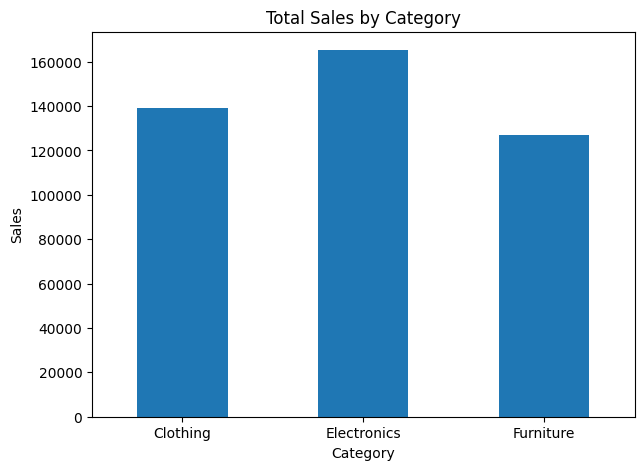

In [6]:
# Visualize Total Sales by Category

category_analysis["Total_Sales"].plot(
    kind="bar",
    figsize=(7,5),
    title="Total Sales by Category"
)

plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

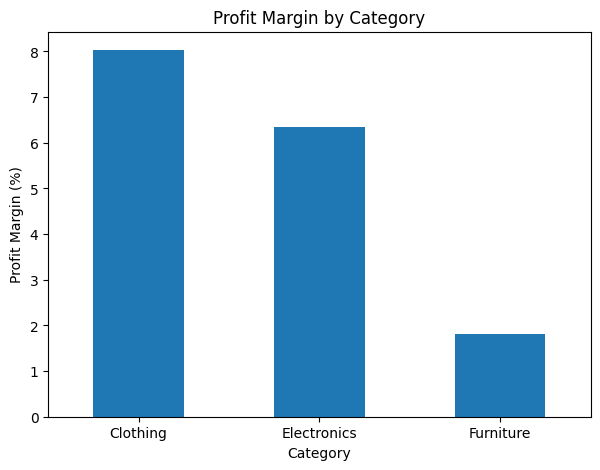

In [7]:
# Visualize Profit Margin by Category

category_analysis["Profit_Margin (%)"].plot(
    kind="bar",
    figsize=(7,5),
    title="Profit Margin by Category"
)

plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

<span style="color:green"> 

## Business Insights

</span>

### Top Performing Category

**Electronics** generated the highest overall sales, indicating strong customer demand and higher transaction values.

### Most Profitable Category

**Clothing** achieved the highest profit margin (8.03%), suggesting better pricing strategy and lower operational costs.

### Underperforming Category

**Furniture** recorded both the lowest sales and the lowest profit margin **(1.81%)**.

This could be due to:

1. High logistics and shipping costs
2. Heavy discounting
3. Higher manufacturing costs
4. Lower inventory turnover

### Recommendation

1. Improve pricing strategy for Furniture.
2. Optimize transportation and supply chain costs.
3. Continue investing in Electronics due to high revenue generation.
4. Expand Clothing offerings since it delivers the highest profitability.

<span style="color:red"> 

# Part 2 : Target Achievement Analysis

</span>

### Objective

In this section, we will:

1. Load the Sales Target dataset.
2. Filter the data for the **Furniture** category.
3. Calculate the Month-over-Month (MoM) percentage change in sales targets.
4. Visualize the target trend over time.
5. Identify months with significant fluctuations in target values.
6. Provide business recommendations for aligning future targets with actual sales performance.

In [8]:
# Load the Sales Target dataset

sales_target_df = pd.read_excel("Sales_target.xlsx")

print("Sales Target Dataset")

display(sales_target_df.head())

Sales Target Dataset


,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900


In [9]:
# Filter data for Furniture category

furniture_target = sales_target_df[
    sales_target_df["Category"] == "Furniture"
].copy()

# Display the dataset

display(furniture_target)

,Month of Order Date,Category,Target
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100
7,2026-11-18,Furniture,11300
8,2026-12-18,Furniture,11400
9,2026-01-19,Furniture,11500


In [10]:
# Convert Month column to datetime

furniture_target["Month of Order Date"] = pd.to_datetime(
    furniture_target["Month of Order Date"],
    format="%b-%y"
)

# Sort by Month

furniture_target = furniture_target.sort_values("Month of Order Date")

display(furniture_target)

,Month of Order Date,Category,Target
9,2026-01-19,Furniture,11500
10,2026-02-19,Furniture,11600
11,2026-03-19,Furniture,11800
0,2026-04-18,Furniture,10400
1,2026-05-18,Furniture,10500
2,2026-06-18,Furniture,10600
3,2026-07-18,Furniture,10800
4,2026-08-18,Furniture,10900
5,2026-09-18,Furniture,11000
6,2026-10-18,Furniture,11100


In [11]:
# Calculate Month-over-Month Percentage Change

furniture_target["MoM Change (%)"] = (
    furniture_target["Target"]
    .pct_change()
    * 100
)

# Round values

furniture_target["MoM Change (%)"] = (
    furniture_target["MoM Change (%)"]
    .round(2)
)

display(furniture_target)

,Month of Order Date,Category,Target,MoM Change (%)
9,2026-01-19,Furniture,11500,NaN
10,2026-02-19,Furniture,11600,0.87
11,2026-03-19,Furniture,11800,1.72
0,2026-04-18,Furniture,10400,-11.86
1,2026-05-18,Furniture,10500,0.96
2,2026-06-18,Furniture,10600,0.95
3,2026-07-18,Furniture,10800,1.89
4,2026-08-18,Furniture,10900,0.93
5,2026-09-18,Furniture,11000,0.92
6,2026-10-18,Furniture,11100,0.91


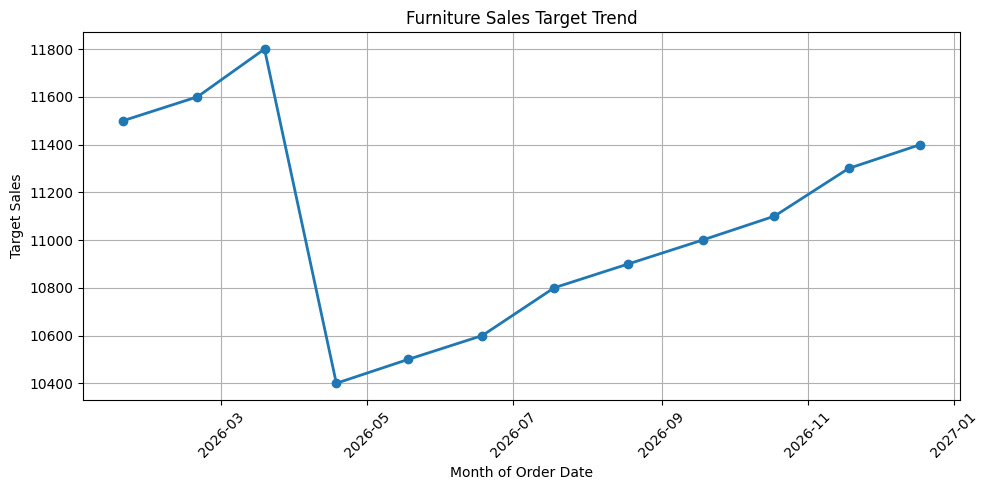

In [12]:
# Plot Furniture Sales Target Trend

plt.figure(figsize=(10,5))

plt.plot(
    furniture_target["Month of Order Date"],
    furniture_target["Target"],
    marker="o",
    linewidth=2
)

plt.title("Furniture Sales Target Trend")

plt.xlabel("Month of Order Date")

plt.ylabel("Target Sales")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [13]:
# Identify the months with the highest increase and decrease in target

highest_increase = furniture_target.loc[
    furniture_target["MoM Change (%)"].idxmax()
]

highest_decrease = furniture_target.loc[
    furniture_target["MoM Change (%)"].idxmin()
]

print("Highest Increase in Target")
display(highest_increase.to_frame().T)

print("\nHighest Decrease in Target")
display(highest_decrease.to_frame().T)

Highest Increase in Target


,Month of Order Date,Category,Target,MoM Change (%)
3,2026-07-18 00:00:00,Furniture,10800,1.89



Highest Decrease in Target


,Month of Order Date,Category,Target,MoM Change (%)
0,2026-04-18 00:00:00,Furniture,10400,-11.86


<span style="color:green"> 

## Business Insights

</span>

### Observations

1. Furniture sales targets remained relatively stable throughout the observed period.
2. The highest month-over-month increase in target was **1.89%**, indicating only a modest upward revision.
3. The largest month-over-month decrease was **11.86%**, suggesting a temporary adjustment in sales expectations.
4. Overall, the targets followed a gradual and predictable trend without major fluctuations.

### Possible Reasons

1. Stable market demand.
2. Conservative sales forecasting.
3. Incremental business growth strategy.
4. Periodic target adjustments based on previous months' performance.

### Recommendations

1. Continue using historical sales data for target forecasting.
2. Review months with target reductions to understand underlying business factors.
3. Monitor actual sales performance to ensure future targets remain realistic and achievable.

<span style="color:red"> 

# Part 3 : Regional Performance Insights

</span>

### Objective

In this section, we will:

1. Identify the top 5 states with the highest number of orders.
2. Calculate the total sales and average profit for each of these states.
3. Visualize the regional sales performance.
4. Identify regional disparities in sales and profitability.
5. Suggest regions that should be prioritized for business improvement.

In [14]:
# Calculate order count for each state

state_order_count = (
    merged_df
    .groupby("State")["Order ID"]
    .count()
    .sort_values(ascending=False)
)

print("Order Count by State")

display(state_order_count)

Order Count by State


State
Madhya Pradesh       340
Maharashtra          290
Gujarat               87
Delhi                 74
Rajasthan             74
Uttar Pradesh         68
West Bengal           63
Bihar                 62
Punjab                60
Karnataka             54
Jammu and Kashmir     49
Nagaland              45
Kerala                45
Goa                   43
Andhra Pradesh        42
Himachal Pradesh      29
Haryana               26
Tamil Nadu            25
Sikkim                24
Name: Order ID, dtype: int64

In [15]:
# Identify the Top 5 states with the highest number of orders

top_5_states = state_order_count.head(5)

print("Top 5 States by Order Count")

display(top_5_states)

Top 5 States by Order Count


State
Madhya Pradesh    340
Maharashtra       290
Gujarat            87
Delhi              74
Rajasthan          74
Name: Order ID, dtype: int64

In [16]:
# Calculate sales and average profit for the Top 5 states

regional_analysis = (
    merged_df[
        merged_df["State"].isin(top_5_states.index)
    ]
    .groupby("State")
    .agg(
        Order_Count=("Order ID", "count"),
        Total_Sales=("Amount", "sum"),
        Average_Profit=("Profit", "mean")
    )
    .sort_values(
        by="Order_Count",
        ascending=False
    )
)

regional_analysis = regional_analysis.round(2)

display(regional_analysis)

,Order_Count,Total_Sales,Average_Profit
State,,,
Madhya Pradesh,340,105140,16.33
Maharashtra,290,95348,21.30
Gujarat,87,21058,5.34
Delhi,74,22531,40.36
Rajasthan,74,21149,16.99


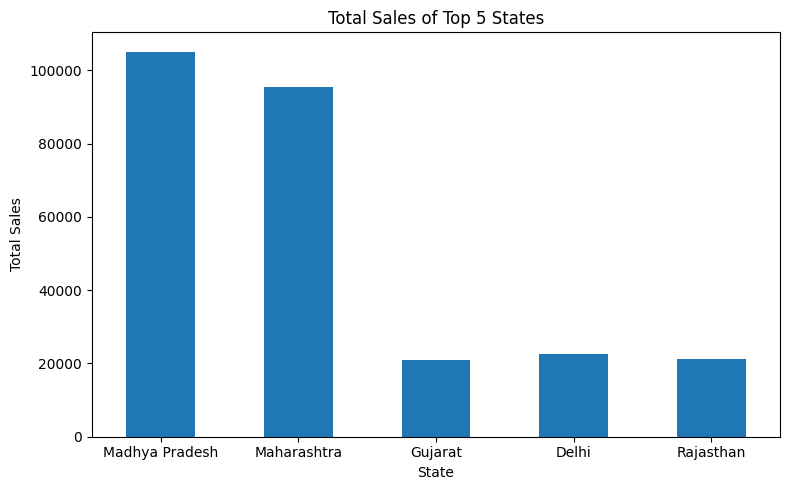

In [17]:
# Plot Total Sales by Top 5 States

plt.figure(figsize=(8,5))

regional_analysis["Total_Sales"].plot(
    kind="bar"
)

plt.title("Total Sales of Top 5 States")

plt.xlabel("State")

plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

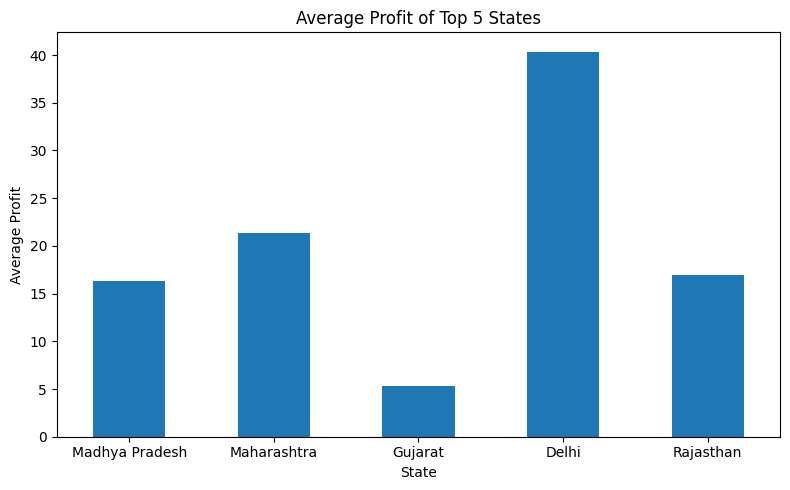

In [18]:
# Plot Average Profit by Top 5 States

plt.figure(figsize=(8,5))

regional_analysis["Average_Profit"].plot(
    kind="bar"
)

plt.title("Average Profit of Top 5 States")

plt.xlabel("State")

plt.ylabel("Average Profit")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

<span style="color:green"> 

## Business Insights

</span>

### Observations

1. The top five states generated the highest order volumes, making them the primary contributors to overall sales.
2. States with high sales did not necessarily achieve the highest average profit, indicating differences in pricing strategies, operational costs, or discount policies.
3. Some regions generated strong revenue but relatively lower profitability, suggesting opportunities for improving operational efficiency.
4. High-performing regions can be used as benchmarks for sales strategies in lower-performing areas.

### Recommendations

1. Prioritize marketing campaigns in states with high demand to maximize revenue.
2. Review pricing and discount strategies in states with lower average profit.
3. Improve supply chain and logistics efficiency in regions with high sales but lower profitability.
4. Investigate customer behavior in underperforming states to identify growth opportunities.